#### ITS69204 — Computer Vision & Natural Language Processing
#### Group Assignment — SDG 4 (Education): College Review Sentiment Analysis
#### NLP Pipeline: TF-IDF (sublinear) + LinearSVC with Decision Boundary Visualisation

---
**SDG Alignment:** SDG 4 — Quality Education  
**Task:** Multi-class sentiment classification (Negative / Neutral / Positive) of student college reviews  
**Model:** LinearSVC — chosen over Naïve Bayes for maximum-margin decision boundaries on text data  
**Dataset:** `collegereview2021.csv` — 18,298 student reviews with ratings 1–10


# Install Libraries

In [1]:
!pip install numpy pandas matplotlib scikit-learn seaborn scipy jupyter ipykernel notebook wordcloud

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.1 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.1 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.0 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 902.3 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 902.3 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 855.6 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 855.6 kB/s eta 0:00:08
   ---------- -----------------

## 1. Imports & Configuration

In [2]:
# ─── Standard library ────
import re
import warnings
import string

# ─── Data handling ─────
import numpy as np
import pandas as pd

# ─── Visualisation ─────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# ─── Scikit-learn: feature engineering ─────
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Scikit-learn: model ──────────────────────────────────────────────────────
from sklearn.svm import LinearSVC

# ─── Scikit-learn: model selection & evaluation ───────────────────────────────
from sklearn.model_selection import train_test_split   # random stratified split
from sklearn.pipeline import Pipeline                  # chains steps cleanly
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ─── Scikit-learn: dimensionality reduction for decision boundary plot ─────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# ─── Scikit-learn: calibration (needed for probability output on LinearSVC) ───
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

# ─── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
})

# ─── Colour palette (consistent across all graphs) ────────────────────────────
CLASS_COLOURS = {
    'Negative': '#E24B4A',   # red
    'Neutral' : '#EF9F27',   # amber
    'Positive': '#1D9E75',   # teal
}
CLASSES = ['Negative', 'Neutral', 'Positive']   # fixed order

print("All imports successful ✓")

All imports successful ✓


## 2. Data Loading
We load the raw CSV and inspect its structure before any processing.


In [3]:
# ─── MODULE: load_data ────────────────────────────────────────────────────────
def load_data(filepath: str) -> pd.DataFrame:
    """
    Load the college review CSV and return a clean DataFrame.

    Parameters
    ----------
    filepath : str
        Path to the raw CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: review (str), rating (float).
    """
    df = pd.read_csv(filepath)

    # Keep only the two columns we need
    df = df[['review', 'rating']].copy()

    # Drop any rows where review text or rating is missing
    df.dropna(subset=['review', 'rating'], inplace=True)

    # Ensure review is a string (safety cast)
    df['review'] = df['review'].astype(str)

    return df


# ── Run ───────────────────────────────────────────────────────────────────────
DATA_PATH = './sample_data/collegereview2021.csv'   # ← adjust path if needed
df_raw = load_data(DATA_PATH)

print(f"Dataset shape : {df_raw.shape}")
print(f"Rating range  : {df_raw['rating'].min()} – {df_raw['rating'].max()}")
print(f"\nSample rows:")
df_raw.head(3)


Dataset shape : (18298, 2)
Rating range  : 1.0 – 10.0

Sample rows:


,review,rating
0,"The annual fee for the course is 1,25,000. Now...",6.0
1,The hostel life and social life in this colleg...,9.7
2,I chose this course because I was interested i...,8.0


## 3. Label Engineering — Rating → Sentiment Class

We convert the continuous rating (1–10) into three sentiment classes:

| Class | Rating range | Rationale |
|-------|-------------|-----------|
| **Negative** | < 5 | Student explicitly dissatisfied |
| **Neutral** | 5 – 7 | Mixed or average experience |
| **Positive** | > 7 | Student satisfied / recommends |

> **Note on class imbalance:** With these thresholds, Negative reviews are only ~2.2% of the data.  
> We handle this using `class_weight='balanced'` in LinearSVC, which automatically up-weights  
> minority classes during training — a critical hyperparameter explained in Section 6.


In [4]:
# ─── MODULE: create_labels ───────
def create_labels(df: pd.DataFrame,
                  neg_threshold: float = 5.0,
                  pos_threshold: float = 7.0) -> pd.DataFrame:
    
    def assign(r):
        if r < neg_threshold:
            return 'Negative'
        elif r > pos_threshold:
            return 'Positive'
        else:
            return 'Neutral'

    df = df.copy()
    df['sentiment'] = df['rating'].apply(assign)
    return df


# ── Run ────
df_labelled = create_labels(df_raw, neg_threshold=5.0, pos_threshold=7.0)

print("Label distribution:")
print(df_labelled['sentiment'].value_counts())
print()
print("Proportion:")
print(df_labelled['sentiment'].value_counts(normalize=True).round(4))


Label distribution:
sentiment
Positive    14092
Neutral      3797
Negative      409
Name: count, dtype: int64

Proportion:
sentiment
Positive    0.7701
Neutral     0.2075
Negative    0.0224
Name: proportion, dtype: float64


## 4. Graph 1 — Class Distribution

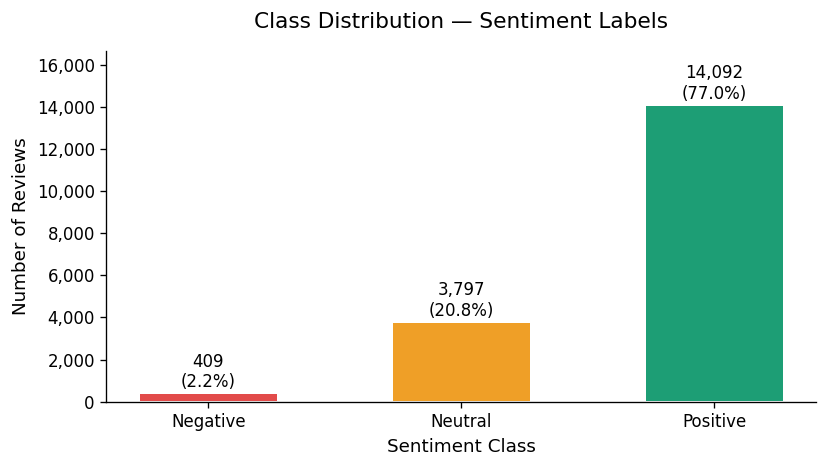


⚠  Class imbalance detected — Negative is only ~2.2% of data.
   Solution: class_weight='balanced' in LinearSVC (explained in Section 6).


In [5]:
# ─── MODULE: plot_class_distribution ─────
def plot_class_distribution(df: pd.DataFrame,label_col: str = 'sentiment') -> None:
    """
    Bar chart showing count and percentage of each sentiment class.
    Helps identify class imbalance before model training.
    """
    counts = df[label_col].value_counts().reindex(CLASSES)
    total  = len(df)

    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.bar(
        CLASSES,
        counts.values,
        color=[CLASS_COLOURS[c] for c in CLASSES],
        edgecolor='white',
        linewidth=1.2,
        width=0.55,
    )

    # Annotate each bar with count + percentage
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='500',
        )

    ax.set_title('Class Distribution — Sentiment Labels', fontsize=13, pad=14)
    ax.set_xlabel('Sentiment Class', fontsize=11)
    ax.set_ylabel('Number of Reviews', fontsize=11)
    ax.set_ylim(0, counts.max() * 1.18)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig('graph1_class_distribution.png', bbox_inches='tight')
    plt.show()
    print("\n⚠  Class imbalance detected — Negative is only ~2.2% of data.")
    print("   Solution: class_weight='balanced' in LinearSVC (explained in Section 6).")


# ── Run ────
plot_class_distribution(df_labelled)


## 5. Graph 2 — Review Length Distribution by Class
Longer, more detailed reviews may correlate with stronger sentiment.


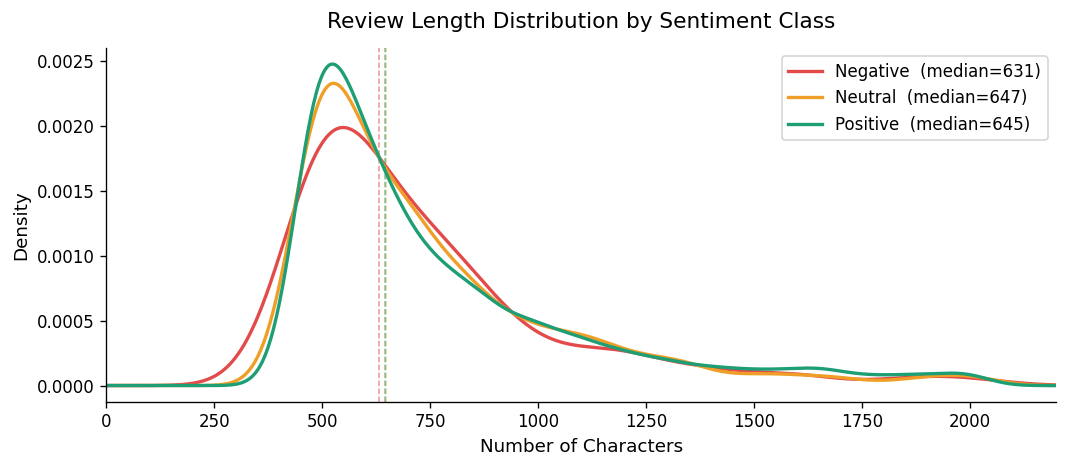

In [6]:
# ─── MODULE: plot_review_length ─────
def plot_review_length(df: pd.DataFrame) -> None:
    """
    KDE + histogram of character-level review length, split by sentiment class.
    Reveals whether review length is a useful signal for sentiment.
    """
    df = df.copy()
    df['char_len'] = df['review'].str.len()

    fig, ax = plt.subplots(figsize=(9, 4))

    for cls in CLASSES:
        subset = df.loc[df['sentiment'] == cls, 'char_len']
        subset.plot.kde(
            ax=ax,
            label=f'{cls}  (median={int(subset.median())})',
            color=CLASS_COLOURS[cls],
            linewidth=2,
        )
        ax.axvline(subset.median(), color=CLASS_COLOURS[cls],
                   linestyle='--', linewidth=0.9, alpha=0.6)

    ax.set_title('Review Length Distribution by Sentiment Class', fontsize=13, pad=12)
    ax.set_xlabel('Number of Characters', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_xlim(0, 2200)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('graph2_review_length.png', bbox_inches='tight')
    plt.show()


# ── Run ──────
plot_review_length(df_labelled)


## 6. Text Preprocessing (NLP Pipeline — Step 2)

Cleaning steps applied in order:
1. Lower-case everything  
2. Remove URLs and email addresses  
3. Remove punctuation & digits  
4. Collapse multiple whitespace  
5. Strip leading/trailing whitespace  

We do **not** remove stopwords here — TF-IDF's IDF weighting naturally  
down-weights high-frequency terms like "the", "is", etc.


In [7]:
# ─── MODULE: clean_text ───────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Apply a reproducible sequence of text-cleaning steps to a single review.

    Steps
    -----
    1. Lower-case  — normalises vocabulary size
    2. Remove URLs — hyperlinks carry no sentiment
    3. Remove email — same reason
    4. Remove punctuation & digits — reduces noise for bag-of-words models
    5. Collapse whitespace — tidy tokenisation

    Parameters
    ----------
    text : str
        Raw review string.

    Returns
    -------
    str
        Cleaned review string.
    """
    # 1. Lower-case
    text = text.lower()

    # 2. Remove URLs (http / https / www)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 4. Remove punctuation and digits
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))

    # 5. Collapse multiple whitespace into single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ─── MODULE: preprocess_dataframe ────────────────────────────────────────────
def preprocess_dataframe(df: pd.DataFrame,
                          text_col: str = 'review') -> pd.DataFrame:
    """
    Apply clean_text() to every row of the DataFrame.
    Returns a copy with a new 'clean_review' column.
    """
    df = df.copy()
    df['clean_review'] = df[text_col].apply(clean_text)

    # Drop any rows that became empty after cleaning
    df = df[df['clean_review'].str.strip().str.len() > 0].reset_index(drop=True)
    return df


# ── Run ───────────────────────────────────────────────────────────────────────
df_clean = preprocess_dataframe(df_labelled)

print(f"Rows before cleaning : {len(df_labelled)}")
print(f"Rows after  cleaning : {len(df_clean)}")
print()
print("Example — raw review (first 200 chars):")
print(df_labelled['review'].iloc[0][:200])
print()
print("Example — cleaned review (first 200 chars):")
print(df_clean['clean_review'].iloc[0][:200])


Rows before cleaning : 18298
Rows after  cleaning : 18298

Example — raw review (first 200 chars):
The annual fee for the course is 1,25,000. Now they are forced to pay the fees on early with total amount. Books and journals are available in less. Extracurricular activities on the campus in a good 

Example — cleaned review (first 200 chars):
the annual fee for the course is now they are forced to pay the fees on early with total amount books and journals are available in less extracurricular activities on the campus in a good manner they 


## 7. Graph 3 — Word Cloud per Sentiment Class
Qualitatively shows the most frequent terms in each class.  
This confirms our cleaning was effective and gives intuition about class vocabulary.


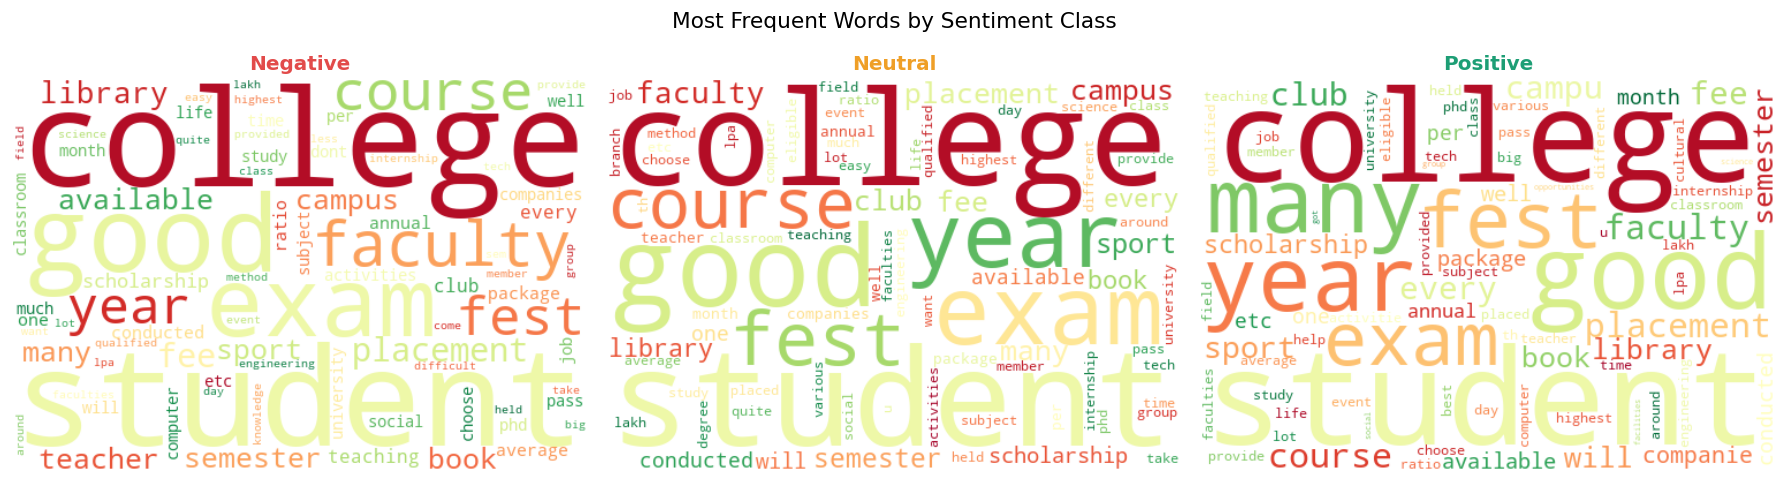

In [8]:
# ─── MODULE: plot_wordclouds ──────────────────────────────────────────────────
def plot_wordclouds(df: pd.DataFrame,
                    text_col: str = 'clean_review') -> None:
    """
    Generate one word cloud per sentiment class side by side.

    Larger words appear more frequently in that class's reviews.
    This is a qualitative sanity-check on our preprocessing.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Most Frequent Words by Sentiment Class', fontsize=13, y=1.01)

    for ax, cls in zip(axes, CLASSES):
        # Concatenate all reviews for this class
        corpus = ' '.join(df.loc[df['sentiment'] == cls, text_col].tolist())

        wc = WordCloud(
            width=500, height=340,
            background_color='white',
            colormap='RdYlGn',        # red→green matches our sentiment scale
            max_words=80,
            collocations=False,        # avoid repeated bigrams
            random_state=42,
        ).generate(corpus)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cls, fontsize=12, color=CLASS_COLOURS[cls], fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('graph3_wordclouds.png', bbox_inches='tight')
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
plot_wordclouds(df_clean)


## 8. Train / Test Split (Dataset Splitting — Step 3)

### Why 80 / 20?
- **80% training** gives the model enough examples of all classes, especially the rare Negative class (~327 samples).  
- **20% testing** provides ~3,660 unseen reviews for reliable evaluation.  
- `stratify=y` ensures the 2.2% Negative minority appears in the same proportion in *both* train and test — without this, Negative reviews could end up entirely in one split.

### Hyperparameter: `random_state`
`random_state=42` is a seed for the random number generator.  
Setting it makes the split **fully reproducible** — anyone re-running the notebook gets the exact same train/test rows.  
The value 42 is conventional; what matters is that it is fixed and documented.


In [9]:
# ─── MODULE: split_data ───────────────────────────────────────────────────────
def split_data(df: pd.DataFrame,
               text_col:  str   = 'clean_review',
               label_col: str   = 'sentiment',
               test_size: float = 0.20,
               random_state: int = 42):
    """
    Split cleaned DataFrame into training and testing sets.

    Parameters
    ----------
    df           : pd.DataFrame  — must contain text_col and label_col
    text_col     : str           — column with cleaned review text
    label_col    : str           — column with sentiment label
    test_size    : float         — fraction reserved for testing (default 0.20 = 20%)
    random_state : int           — seed for reproducibility (default 42)

    Returns
    -------
    X_train, X_test : pd.Series  — text arrays
    y_train, y_test : pd.Series  — label arrays

    Notes
    -----
    stratify=y_all  → preserves class proportions in both splits.
    This is essential when classes are imbalanced (Negative ≈ 2.2%).
    """
    X_all = df[text_col]
    y_all = df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size    = test_size,      # 20% test
        random_state = random_state,   # reproducibility seed
        stratify     = y_all,          # preserve class ratios ← critical
    )

    return X_train, X_test, y_train, y_test


# ── Run ───────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = split_data(df_clean)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print()
print("Training class distribution (stratification check):")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Testing class distribution (should match training):")
print(y_test.value_counts(normalize=True).round(4))


Training samples : 14,638
Testing  samples : 3,660

Training class distribution (stratification check):
sentiment
Positive    0.7701
Neutral     0.2075
Negative    0.0223
Name: proportion, dtype: float64

Testing class distribution (should match training):
sentiment
Positive    0.7702
Neutral     0.2074
Negative    0.0224
Name: proportion, dtype: float64


## 9. NLP Pipeline — TF-IDF + LinearSVC (Steps 3 & 4)

### Why TF-IDF instead of Count Vectorizer?
| Feature | Count Vectorizer | TF-IDF |
|---------|-----------------|--------|
| Gives raw word counts | ✓ | ✗ |
| Down-weights common words across docs | ✗ | ✓ (IDF component) |
| Handles long vs short reviews fairly | ✗ | ✓ (TF normalisation) |

### Why LinearSVC instead of Naïve Bayes?
Naïve Bayes assumes every word is **conditionally independent** given the class.  
This fails in natural language — "not good" is very different from "good" alone.  
LinearSVC finds the **maximum-margin hyperplane** that best separates classes,  
making no independence assumption. It consistently outperforms NB on longer text.

### Hyperparameter explanations

| Parameter | Where | Value | Why |
|-----------|-------|-------|-----|
| `max_features` | TfidfVectorizer | 30,000 | Limits vocabulary to the 30k most important terms — reduces noise and memory |
| `ngram_range` | TfidfVectorizer | (1,2) | Includes unigrams ("good") AND bigrams ("not good") — captures negation |
| `sublinear_tf` | TfidfVectorizer | True | Replaces raw TF with 1+log(TF) — dampens the effect of words repeated 100× vs 10× |
| `min_df` | TfidfVectorizer | 3 | Ignores terms appearing in fewer than 3 documents — removes typos/rare noise |
| `C` | LinearSVC | 1.0 | Regularisation strength — higher C = tighter fit to training data; 1.0 is a balanced default |
| `class_weight` | LinearSVC | 'balanced' | Automatically adjusts loss weights inversely proportional to class frequency — fixes the Negative class imbalance |
| `max_iter` | LinearSVC | 2000 | Maximum optimisation iterations — increased from default 1000 to ensure convergence |


In [10]:
# ─── MODULE: build_pipeline ───────────────────────────────────────────────────
def build_pipeline(
    max_features : int   = 30_000,
    ngram_range  : tuple = (1, 2),
    sublinear_tf : bool  = True,
    min_df       : int   = 3,
    C            : float = 1.0,
    max_iter     : int   = 2_000,
) -> Pipeline:
    """
    Construct and return a scikit-learn Pipeline of:
        TfidfVectorizer  →  LinearSVC

    Parameters
    ----------
    max_features : int
        Maximum number of TF-IDF features (vocabulary size cap).
        Reduces noise from rare/misspelled terms.

    ngram_range : tuple (min_n, max_n)
        Word n-gram range.
        (1,2) = unigrams + bigrams → captures 'not good', 'very poor', etc.

    sublinear_tf : bool
        If True, applies log(1 + tf) instead of raw tf.
        Reduces the dominance of highly repeated words in long reviews.

    min_df : int
        Ignore terms appearing in fewer than min_df documents.
        Removes very rare words that are likely typos or noise.

    C : float
        Regularisation parameter for LinearSVC.
        Smaller C → stronger regularisation (simpler model, may underfit).
        Larger C → less regularisation (complex model, may overfit).
        Default 1.0 is a well-tested starting point.

    max_iter : int
        Maximum number of iterations for the SVM solver.
        Increase if convergence warnings appear.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Unfitted pipeline ready for .fit() / .predict().
    """
    vectorizer = TfidfVectorizer(
        max_features = max_features,
        ngram_range  = ngram_range,
        sublinear_tf = sublinear_tf,
        min_df       = min_df,
        strip_accents = 'unicode',   # handles special characters in college names
    )

    classifier = LinearSVC(
        C            = C,
        class_weight = 'balanced',   # critical for 2.2% Negative minority
        max_iter     = max_iter,
        random_state = 42,
    )

    pipeline = Pipeline([
        ('tfidf', vectorizer),        # Step 1: text → TF-IDF matrix
        ('svm',   classifier),        # Step 2: TF-IDF matrix → class label
    ])

    return pipeline


# ── Run ───────────────────────────────────────────────────────────────────────
pipeline = build_pipeline()
print("Pipeline built:")
print(pipeline)


Pipeline built:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, min_df=3,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('svm',
                 LinearSVC(class_weight='balanced', max_iter=2000,
                           random_state=42))])


## 10. Model Training

In [11]:
# ─── MODULE: train_model ────────
def train_model(pipeline: Pipeline,
                X_train: pd.Series,
                y_train: pd.Series) -> Pipeline:
    """
    Fit the pipeline on training data.

    What happens internally
    -----------------------
    1. TfidfVectorizer.fit_transform(X_train)
       → Learns vocabulary and IDF weights from training text only
       → Converts each review to a sparse TF-IDF vector of shape (n_docs, max_features)

    2. LinearSVC.fit(X_tfidf, y_train)
       → Solves: minimise ||w||² + C·Σ max(0, 1 − yᵢ·(w·xᵢ + b))
       → Finds the maximum-margin hyperplane separating the three classes
       → Uses One-vs-Rest strategy for multi-class (3 binary classifiers)

    Parameters
    ----------
    pipeline : Pipeline  — unfitted pipeline
    X_train  : pd.Series — cleaned training reviews
    y_train  : pd.Series — training sentiment labels

    Returns
    -------
    Pipeline — fitted pipeline (vectorizer weights + SVM weights stored inside)
    """
    pipeline.fit(X_train, y_train)
    return pipeline


# ── Run ───────────────────────────────────────────────────────────────────────
import time
t0 = time.time()
pipeline = train_model(pipeline, X_train, y_train)
elapsed = time.time() - t0

vocab_size = len(pipeline.named_steps['tfidf'].vocabulary_)
print(f"Training complete in {elapsed:.1f}s")
print(f"TF-IDF vocabulary size : {vocab_size:,} features")
print(f"SVM classes learned    : {list(pipeline.named_steps['svm'].classes_)}")


Training complete in 7.5s
TF-IDF vocabulary size : 30,000 features
SVM classes learned    : ['Negative', 'Neutral', 'Positive']


## 11. Model Evaluation & Metrics

### Metric definitions

| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **Accuracy** | correct / total | Overall correctness — misleading when classes are imbalanced |
| **Precision** | TP / (TP+FP) | Of all reviews predicted as class X, how many actually are X? |
| **Recall** | TP / (TP+FN) | Of all actual class X reviews, how many did we catch? |
| **F1-Score** | 2·P·R / (P+R) | Harmonic mean of Precision and Recall — best single metric for imbalanced data |

We report **macro-averaged** F1 (treats all classes equally regardless of size) — important given our imbalanced Negative class.


In [12]:
# ─── MODULE: evaluate_model ───────────────────────────────────────────────────
def evaluate_model(pipeline: Pipeline,
                   X_test:  pd.Series,
                   y_test:  pd.Series) -> dict:
    """
    Generate predictions and compute all evaluation metrics.

    Parameters
    ----------
    pipeline : Pipeline  — fitted pipeline
    X_test   : pd.Series — cleaned test reviews
    y_test   : pd.Series — true test labels

    Returns
    -------
    dict with keys:
        y_pred       — predicted labels (array)
        accuracy     — float
        precision    — dict {class: value} + 'macro' key
        recall       — dict {class: value} + 'macro' key
        f1           — dict {class: value} + 'macro' key
        report       — full classification report string
        conf_matrix  — np.ndarray confusion matrix
    """
    y_pred = pipeline.predict(X_test)

    results = {
        'y_pred'     : y_pred,
        'accuracy'   : accuracy_score(y_test, y_pred),
        'precision'  : {
            **{c: precision_score(y_test, y_pred, labels=[c], average='macro')
               for c in CLASSES},
            'macro': precision_score(y_test, y_pred, average='macro'),
        },
        'recall'     : {
            **{c: recall_score(y_test, y_pred, labels=[c], average='macro')
               for c in CLASSES},
            'macro': recall_score(y_test, y_pred, average='macro'),
        },
        'f1'         : {
            **{c: f1_score(y_test, y_pred, labels=[c], average='macro')
               for c in CLASSES},
            'macro': f1_score(y_test, y_pred, average='macro'),
        },
        'report'     : classification_report(y_test, y_pred,
                                              target_names=CLASSES),
        'conf_matrix': confusion_matrix(y_test, y_pred,
                                         labels=CLASSES),
    }
    return results


# ── Run ───────────────────────────────────────────────────────────────────────
results = evaluate_model(pipeline, X_test, y_test)

print("=" * 55)
print(f"  Overall Accuracy : {results['accuracy']:.4f}  ({results['accuracy']*100:.2f}%)")
print(f"  Macro Precision  : {results['precision']['macro']:.4f}")
print(f"  Macro Recall     : {results['recall']['macro']:.4f}")
print(f"  Macro F1-Score   : {results['f1']['macro']:.4f}")
print("=" * 55)
print()
print("Full Classification Report:")
print(results['report'])


  Overall Accuracy : 0.8227  (82.27%)
  Macro Precision  : 0.7917
  Macro Recall     : 0.6159
  Macro F1-Score   : 0.6745

Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.44      0.59        82
     Neutral       0.61      0.48      0.54       759
    Positive       0.86      0.93      0.89      2819

    accuracy                           0.82      3660
   macro avg       0.79      0.62      0.67      3660
weighted avg       0.81      0.82      0.81      3660



## 12. Graph 4 — Confusion Matrix

The confusion matrix shows:
- **Diagonal** = correctly classified reviews  
- **Off-diagonal** = misclassifications (e.g., Neutral predicted as Positive)

We display both raw counts AND normalised (row %) to handle the class imbalance visually.


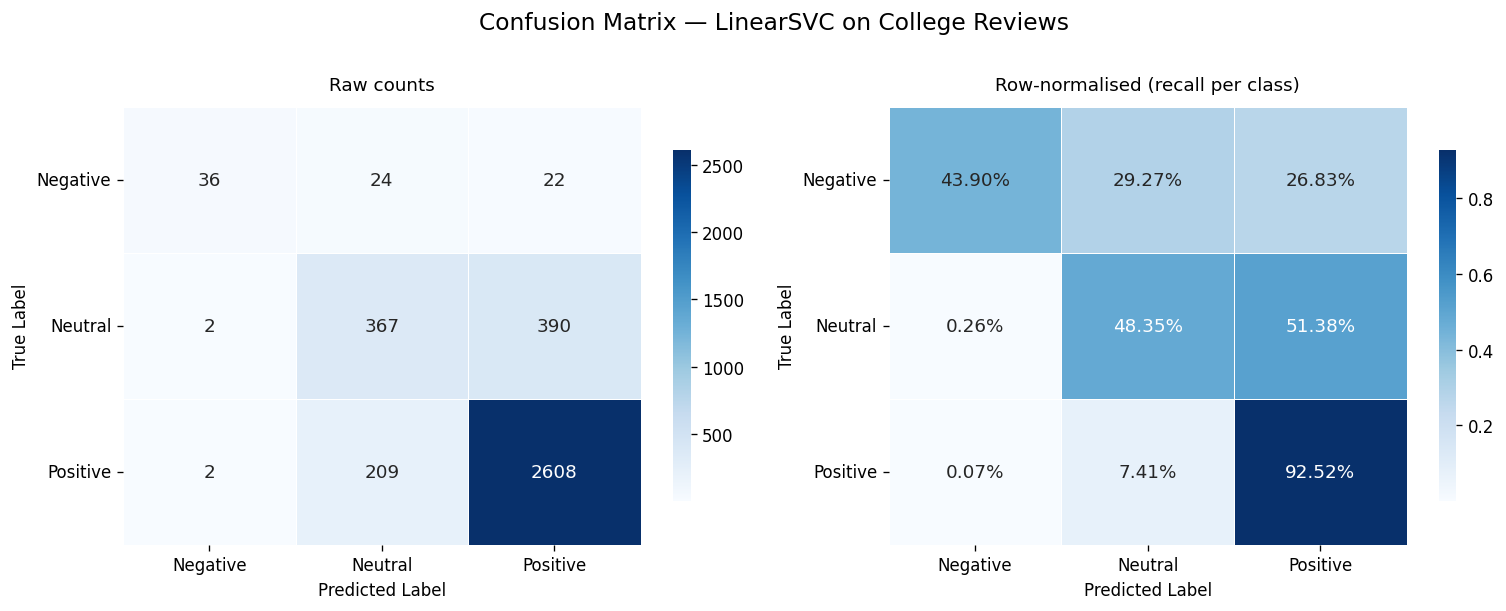

In [13]:
# ─── MODULE: plot_confusion_matrix ───────────────────────────────────────────
def plot_confusion_matrix(conf_matrix: np.ndarray,
                           classes: list,
                           title: str = 'Confusion Matrix') -> None:
    """
    Plot a styled confusion matrix heatmap with both raw counts and percentages.

    Parameters
    ----------
    conf_matrix : np.ndarray
        Square confusion matrix from sklearn.metrics.confusion_matrix.
        Shape: (n_classes, n_classes).
        conf_matrix[i, j] = number of true-class-i samples predicted as class-j.

    classes : list of str
        Class names in the same order used to produce conf_matrix.

    title : str
        Plot title.

    How to read
    -----------
    - Rows  = true labels
    - Cols  = predicted labels
    - Ideal = high values on the main diagonal, zeros elsewhere
    """
    # Normalise row-wise (what % of true class X was predicted correctly?)
    cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=14, y=1.01)

    for ax, data, fmt, subtitle in zip(
        axes,
        [conf_matrix, cm_norm],
        ['.0f',       '.2%'],
        ['Raw counts', 'Row-normalised (recall per class)'],
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes,
            linewidths=0.6,
            linecolor='white',
            ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11},
        )
        ax.set_title(subtitle, fontsize=11, pad=10)
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.set_ylabel('True Label', fontsize=10)
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig('graph4_confusion_matrix.png', bbox_inches='tight')
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
plot_confusion_matrix(results['conf_matrix'], CLASSES,
                      title='Confusion Matrix — LinearSVC on College Reviews')


## 13. Graph 5 — Precision / Recall / F1 per Class

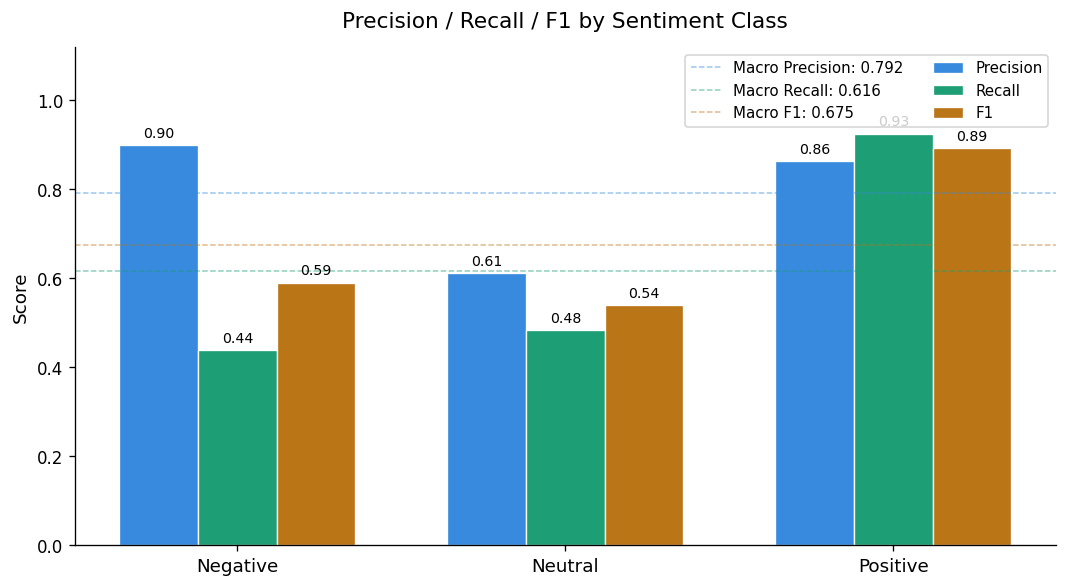

In [14]:
# ─── MODULE: plot_metrics_bar ─────────────────────────────────────────────────
def plot_metrics_bar(results: dict) -> None:
    """
    Grouped bar chart showing Precision, Recall, and F1 for each class.
    Makes it easy to spot which class the model struggles with most.
    """
    metrics = ['Precision', 'Recall', 'F1']
    x      = np.arange(len(CLASSES))
    width  = 0.24

    fig, ax = plt.subplots(figsize=(9, 5))

    bar_data = [
        [results['precision'][c] for c in CLASSES],
        [results['recall'][c]    for c in CLASSES],
        [results['f1'][c]        for c in CLASSES],
    ]
    bar_colours = ['#378ADD', '#1D9E75', '#BA7517']

    for i, (vals, colour, label) in enumerate(zip(bar_data, bar_colours, metrics)):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width,
                      label=label, color=colour,
                      edgecolor='white', linewidth=0.8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{v:.2f}',
                    ha='center', va='bottom', fontsize=8.5)

    # Macro averages as horizontal dashed lines
    for val, colour, label in zip(
        [results['precision']['macro'],
         results['recall']['macro'],
         results['f1']['macro']],
        bar_colours, metrics
    ):
        ax.axhline(val, linestyle='--', linewidth=0.9,
                   color=colour, alpha=0.5,
                   label=f'Macro {label}: {val:.3f}')

    ax.set_title('Precision / Recall / F1 by Sentiment Class', fontsize=13, pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=9, ncol=2, loc='upper right')

    plt.tight_layout()
    plt.savefig('graph5_metrics_bar.png', bbox_inches='tight')
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
plot_metrics_bar(results)


## 14. Graph 6 — Top TF-IDF Features per Class

LinearSVC learns a **weight vector** for each class.  
The highest-weight features are the words most strongly associated with that sentiment class.  
This graph makes the model interpretable — we can see *why* it predicts each class.


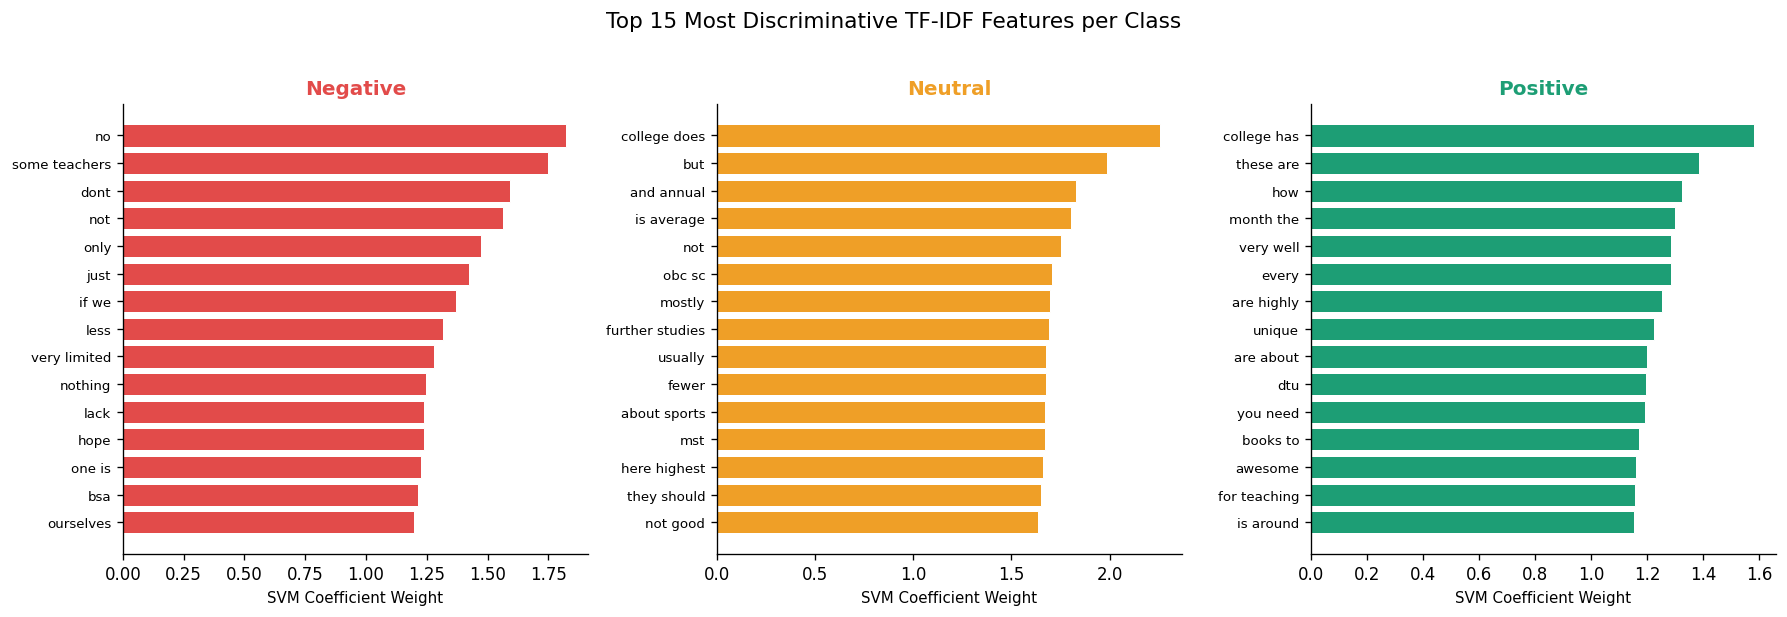

In [15]:
# ─── MODULE: plot_top_features ────────────────────────────────────────────────
def plot_top_features(pipeline: Pipeline,
                       classes: list,
                       top_n: int = 15) -> None:
    """
    Horizontal bar chart of the top-N most discriminative TF-IDF features
    for each sentiment class, derived from the LinearSVC coefficient weights.

    Parameters
    ----------
    pipeline : Pipeline  — fitted pipeline containing 'tfidf' and 'svm' steps
    classes  : list      — class labels in the order the SVM was trained on
    top_n    : int       — number of top features to display per class

    How it works
    ------------
    LinearSVC produces a coefficient matrix of shape (n_classes, n_features).
    Each row is the weight vector for one class (One-vs-Rest).
    The features with the highest weights are the most predictive for that class.
    """
    feature_names = np.array(pipeline.named_steps['tfidf'].get_feature_names_out())
    coef          = pipeline.named_steps['svm'].coef_   # shape: (n_classes, n_features)

    fig, axes = plt.subplots(1, len(classes), figsize=(15, 5), sharey=False)
    fig.suptitle(f'Top {top_n} Most Discriminative TF-IDF Features per Class',
                 fontsize=13, y=1.02)

    for ax, cls, coef_row in zip(axes, classes, coef):
        top_idx    = np.argsort(coef_row)[-top_n:]
        top_words  = feature_names[top_idx]
        top_scores = coef_row[top_idx]

        ax.barh(top_words, top_scores,
                color=CLASS_COLOURS[cls], edgecolor='white', linewidth=0.6)
        ax.set_title(cls, fontsize=12,
                     color=CLASS_COLOURS[cls], fontweight='bold')
        ax.set_xlabel('SVM Coefficient Weight', fontsize=9)
        ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig('graph6_top_features.png', bbox_inches='tight')
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
plot_top_features(pipeline, CLASSES, top_n=15)


## 15. Graph 7 — Decision Boundary Visualisation (PCA 2D)

This is the **key differentiator** from Naïve Bayes:  
LinearSVC produces **hard, linear decision boundaries** that maximise the margin between classes.

Since TF-IDF vectors are high-dimensional (30,000 features), we use **PCA** to project them  
into 2D for visualisation. The decision regions are then redrawn in this 2D space.

**PCA (Principal Component Analysis)** finds the two directions of maximum variance  
in the data — effectively the most "interesting" axes. Points close together in 2D  
were also close in the original 30,000-dimensional space.


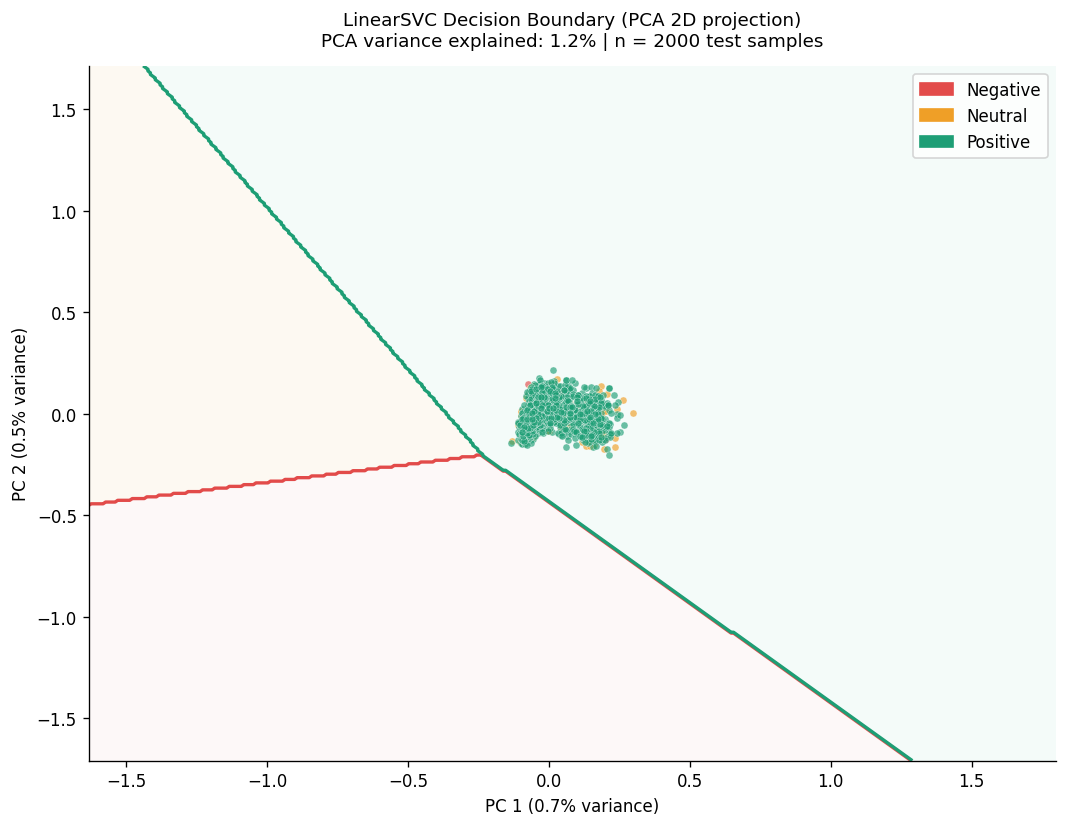

PCA variance explained by 2 components: 1.21%
Note: Decision boundary shown in 2D PCA space.
The original model operates in 30,000-dimensional TF-IDF space.


In [16]:
# ─── MODULE: plot_decision_boundary ──────────────────────────────────────────
def plot_decision_boundary(pipeline: Pipeline,
                            X_test:  pd.Series,
                            y_test:  pd.Series,
                            n_sample: int = 2000) -> None:
    """
    Visualise LinearSVC decision boundaries by projecting TF-IDF vectors
    into 2D with PCA, then training a fresh LinearSVC on those 2D coordinates.

    Parameters
    ----------
    pipeline  : Pipeline  — fitted original pipeline
    X_test    : pd.Series — cleaned test text
    y_test    : pd.Series — true labels
    n_sample  : int       — number of test points to plot (performance limit)

    Steps
    -----
    1. Transform test text to TF-IDF vectors using the fitted vectoriser.
    2. Apply PCA(n_components=2) to get 2D coordinates.
    3. Fit a new LinearSVC directly on the 2D PCA coordinates.
       (This 2D model approximates the original; exact boundaries differ.)
    4. Create a mesh grid over the 2D space.
    5. Predict class for every mesh point → shade regions.
    6. Scatter true test points on top.
    """
    le = LabelEncoder()
    le.fit(CLASSES)

    # 1. TF-IDF transform (no refit — use the already-fitted vectoriser)
    X_tfidf = pipeline.named_steps['tfidf'].transform(X_test)

    # 2. PCA projection → 2D
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_tfidf.toarray())

    var_explained = pca.explained_variance_ratio_.sum() * 100

    # Sample for plotting speed
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_2d), size=min(n_sample, len(X_2d)), replace=False)
    X_plot = X_2d[idx]
    y_plot = np.array(y_test)[idx]

    # 3. Fit LinearSVC in 2D (for drawing boundaries)
    svm_2d = LinearSVC(C=1.0, class_weight='balanced',
                        max_iter=3000, random_state=42)
    svm_2d.fit(X_2d, np.array(y_test))

    # 4. Mesh grid
    pad  = 1.5
    x_min, x_max = X_2d[:, 0].min() - pad, X_2d[:, 0].max() + pad
    y_min, y_max = X_2d[:, 1].min() - pad, X_2d[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400),
    )

    # 5. Predict on mesh
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_enc = le.transform(Z).reshape(xx.shape)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 7))

    region_colours = ['#FCEBEB', '#FAEEDA', '#E1F5EE']   # light red/amber/teal fills
    ax.contourf(xx, yy, Z_enc, alpha=0.35,
                levels=[-0.5, 0.5, 1.5, 2.5],
                colors=region_colours)
    ax.contour(xx, yy, Z_enc,
               levels=[0.5, 1.5],
               colors=['#E24B4A', '#1D9E75'],
               linewidths=2.0)

    # 6. Scatter test points
    for cls in CLASSES:
        mask = y_plot == cls
        ax.scatter(
            X_plot[mask, 0], X_plot[mask, 1],
            c=CLASS_COLOURS[cls], label=cls,
            s=18, alpha=0.65, edgecolors='white', linewidths=0.3,
        )

    ax.set_title(
        f'LinearSVC Decision Boundary (PCA 2D projection)\n'
        f'PCA variance explained: {var_explained:.1f}% | '
        f'n = {n_sample} test samples',
        fontsize=11, pad=12,
    )
    ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)

    legend_patches = [
        mpatches.Patch(color=CLASS_COLOURS[c], label=c) for c in CLASSES
    ]
    ax.legend(handles=legend_patches, fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.savefig('graph7_decision_boundary.png', bbox_inches='tight')
    plt.show()
    print(f"PCA variance explained by 2 components: {var_explained:.2f}%")
    print("Note: Decision boundary shown in 2D PCA space.")
    print("The original model operates in 30,000-dimensional TF-IDF space.")


# ── Run ───────────────────────────────────────────────────────────────────────
plot_decision_boundary(pipeline, X_test, y_test, n_sample=2000)


## 16. Graph 8 — ROC Curve (One-vs-Rest, Multi-Class)

The ROC curve plots **True Positive Rate** vs **False Positive Rate** at different thresholds.  
AUC (Area Under Curve) = 1.0 is perfect; AUC = 0.5 is random guessing.  

Since LinearSVC does not natively output probabilities, we use  
`CalibratedClassifierCV` to convert decision scores to probability estimates.


Training calibrated models for ROC (this may take ~30 seconds)...


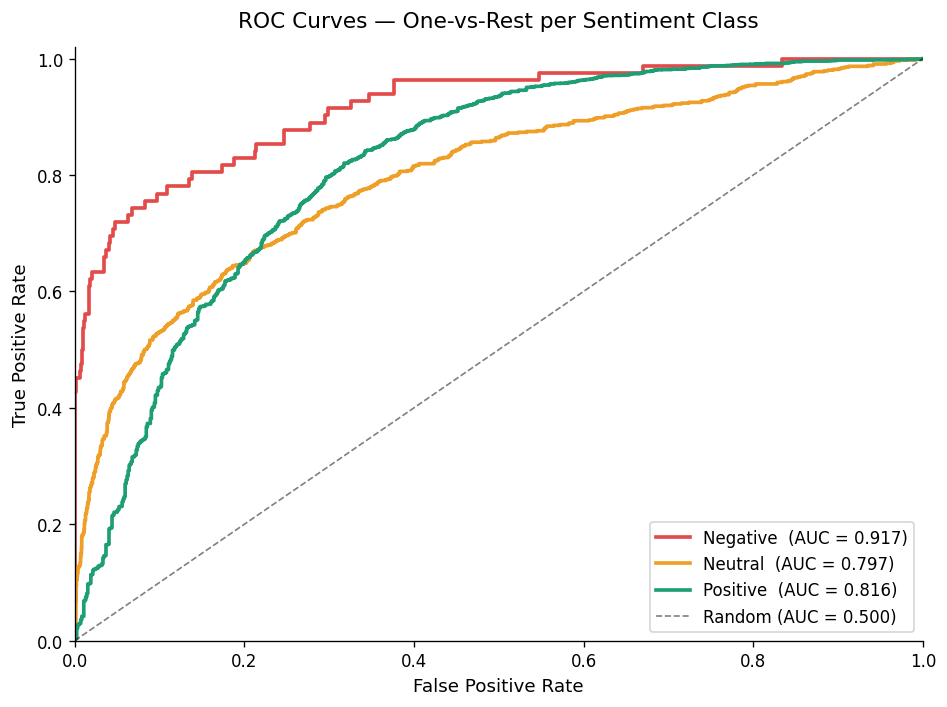

In [17]:
# ─── MODULE: plot_roc_curves ──────────────────────────────────────────────────
def plot_roc_curves(pipeline: Pipeline,
                    X_train: pd.Series,
                    y_train: pd.Series,
                    X_test:  pd.Series,
                    y_test:  pd.Series) -> None:
    """
    Plot One-vs-Rest ROC curves for each sentiment class.

    Why CalibratedClassifierCV?
    ---------------------------
    LinearSVC outputs raw decision scores (not probabilities).
    CalibratedClassifierCV wraps it and uses isotonic/sigmoid regression
    to map scores → probabilities, enabling ROC curve computation.

    Parameters
    ----------
    pipeline : Pipeline  — fitted pipeline (used to extract vectoriser)
    X_train  : pd.Series — clean training text
    y_train  : pd.Series — training labels
    X_test   : pd.Series — clean test text
    y_test   : pd.Series — true test labels
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    # Binarise labels for one-vs-rest (OvR)
    y_train_bin = label_binarize(y_train, classes=CLASSES)
    y_test_bin  = label_binarize(y_test,  classes=CLASSES)

    # Transform text with the already-fitted TF-IDF vectoriser
    tfidf        = pipeline.named_steps['tfidf']
    X_train_tfidf = tfidf.transform(X_train)
    X_test_tfidf  = tfidf.transform(X_test)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, cls in enumerate(CLASSES):
        # Calibrated SVM for probability output
        cal_svm = CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight='balanced',
                      max_iter=2000, random_state=42),
            cv=3,
        )
        cal_svm.fit(X_train_tfidf, y_train)

        # Probability of the positive class in OvR
        y_score = cal_svm.predict_proba(X_test_tfidf)[:, i]

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score)
        roc_auc      = auc(fpr, tpr)

        ax.plot(fpr, tpr,
                color=CLASS_COLOURS[cls], linewidth=2.2,
                label=f'{cls}  (AUC = {roc_auc:.3f})')

    # Diagonal = random classifier baseline
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')

    ax.set_title('ROC Curves — One-vs-Rest per Sentiment Class', fontsize=13, pad=12)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    plt.tight_layout()
    plt.savefig('graph8_roc_curves.png', bbox_inches='tight')
    plt.show()


# ── Run (takes ~30s due to CalibratedClassifierCV training) ───────────────────
print("Training calibrated models for ROC (this may take ~30 seconds)...")
plot_roc_curves(pipeline, X_train, y_train, X_test, y_test)


## 17. Final Results Summary

In [18]:
# ─── MODULE: print_summary ────────────────────────────────────────────────────
def print_summary(results: dict) -> None:
    """
    Display a clean, formatted summary of all evaluation metrics.
    Use this table directly in the report.
    """
    print("╔══════════════════════════════════════════════════════════╗")
    print("║         FINAL MODEL EVALUATION SUMMARY                  ║")
    print("║         LinearSVC + TF-IDF | College Review Sentiment   ║")
    print("╠══════════════════════════════════════════════════════════╣")
    print(f"║  Overall Accuracy  : {results['accuracy']:.4f}                           ║")
    print(f"║  Macro Precision   : {results['precision']['macro']:.4f}                           ║")
    print(f"║  Macro Recall      : {results['recall']['macro']:.4f}                           ║")
    print(f"║  Macro F1-Score    : {results['f1']['macro']:.4f}                           ║")
    print("╠══════════════════════════════════════════════════════════╣")
    print("║  Per-class breakdown:                                    ║")
    for cls in CLASSES:
        p = results['precision'][cls]
        r = results['recall'][cls]
        f = results['f1'][cls]
        print(f"║    {cls:<10}  P={p:.3f}  R={r:.3f}  F1={f:.3f}            ║")
    print("╚══════════════════════════════════════════════════════════╝")

    # Summary DataFrame (easy to copy into report)
    rows = []
    for cls in CLASSES:
        rows.append({
            'Class'    : cls,
            'Precision': round(results['precision'][cls], 4),
            'Recall'   : round(results['recall'][cls], 4),
            'F1-Score' : round(results['f1'][cls], 4),
        })
    rows.append({
        'Class'    : 'MACRO AVG',
        'Precision': round(results['precision']['macro'], 4),
        'Recall'   : round(results['recall']['macro'], 4),
        'F1-Score' : round(results['f1']['macro'], 4),
    })
    df_metrics = pd.DataFrame(rows).set_index('Class')
    print()
    return df_metrics


# ── Run ───────────────────────────────────────────────────────────────────────
df_metrics = print_summary(results)
df_metrics


╔══════════════════════════════════════════════════════════╗
║         FINAL MODEL EVALUATION SUMMARY                  ║
║         LinearSVC + TF-IDF | College Review Sentiment   ║
╠══════════════════════════════════════════════════════════╣
║  Overall Accuracy  : 0.8227                           ║
║  Macro Precision   : 0.7917                           ║
║  Macro Recall      : 0.6159                           ║
║  Macro F1-Score    : 0.6745                           ║
╠══════════════════════════════════════════════════════════╣
║  Per-class breakdown:                                    ║
║    Negative    P=0.900  R=0.439  F1=0.590            ║
║    Neutral     P=0.612  R=0.484  F1=0.540            ║
║    Positive    P=0.864  R=0.925  F1=0.893            ║
╚══════════════════════════════════════════════════════════╝



,Precision,Recall,F1-Score
Class,,,
Negative,0.9000,0.4390,0.5902
Neutral,0.6117,0.4835,0.5401
Positive,0.8636,0.9252,0.8933
MACRO AVG,0.7917,0.6159,0.6745


## 18. Model Comparison — Naive Bayes vs LinearSVC

We now train **Multinomial Naive Bayes** with both **Count Vectorizer** and **TF-IDF**  
to compare against our LinearSVC baseline.

### Why Three Models?
1. **Naive Bayes + Count** — baseline, fastest, assumes word independence  
2. **Naive Bayes + TF-IDF** — same classifier but with weighted features  
3. **LinearSVC + TF-IDF** — our main model, finds decision boundaries without independence assumption

This comparison quantifies the trade-off between **simplicity/speed** (Naive Bayes)  
and **accuracy** (LinearSVC).

In [19]:
# ─── MODULE: build_naive_bayes_pipelines ─────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

def build_naive_bayes_pipelines(
    max_features: int = 30_000,
    ngram_range: tuple = (1, 2),
    min_df: int = 3,
) -> tuple:
    """
    Build two Naive Bayes pipelines:
    1. CountVectorizer + MultinomialNB
    2. TfidfVectorizer + MultinomialNB

    Parameters
    ----------
    max_features : int
        Maximum vocabulary size
    ngram_range : tuple
        (min_n, max_n) for n-grams
    min_df : int
        Minimum document frequency

    Returns
    -------
    (pipeline_count, pipeline_tfidf) : tuple of Pipeline objects
    """
    # Pipeline 1: Count Vectorizer + Naive Bayes
    count_vec = CountVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        strip_accents='unicode',
    )
    nb_classifier = MultinomialNB(alpha=1.0)
    pipeline_count = Pipeline([
        ('count', count_vec),
        ('nb', nb_classifier),
    ])

    # Pipeline 2: TF-IDF Vectorizer + Naive Bayes
    tfidf_vec = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        sublinear_tf=True,
        min_df=min_df,
        strip_accents='unicode',
    )
    nb_classifier_tfidf = MultinomialNB(alpha=1.0)
    pipeline_tfidf = Pipeline([
        ('tfidf', tfidf_vec),
        ('nb', nb_classifier_tfidf),
    ])

    return pipeline_count, pipeline_tfidf


# ── Train both Naive Bayes models ─────────────────────────────────────────────
print("Training Naive Bayes models...")
t0 = time.time()
pipeline_nb_count, pipeline_nb_tfidf = build_naive_bayes_pipelines()

pipeline_nb_count.fit(X_train, y_train)
elapsed_count = time.time() - t0

t0 = time.time()
pipeline_nb_tfidf.fit(X_train, y_train)
elapsed_tfidf = time.time() - t0

print(f"✓ Naive Bayes + Count      trained in {elapsed_count:.2f}s")
print(f"✓ Naive Bayes + TF-IDF     trained in {elapsed_tfidf:.2f}s")
print()

# Evaluate all three models
results_nb_count = evaluate_model(pipeline_nb_count, X_test, y_test)
results_nb_tfidf = evaluate_model(pipeline_nb_tfidf, X_test, y_test)

print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':<12} {'Macro F1':<12}")
print("-" * 60)
print(f"{'Naive Bayes + Count':<30} {results_nb_count['accuracy']:.4f}        {results_nb_count['f1']['macro']:.4f}")
print(f"{'Naive Bayes + TF-IDF':<30} {results_nb_tfidf['accuracy']:.4f}        {results_nb_tfidf['f1']['macro']:.4f}")
print(f"{'LinearSVC + TF-IDF (Main)':<30} {results['accuracy']:.4f}        {results['f1']['macro']:.4f}")
print("=" * 60)


Training Naive Bayes models...
✓ Naive Bayes + Count      trained in 5.05s
✓ Naive Bayes + TF-IDF     trained in 4.94s

Model Performance Comparison
Model                          Accuracy     Macro F1    
------------------------------------------------------------
Naive Bayes + Count            0.7814        0.6002
Naive Bayes + TF-IDF           0.7732        0.3001
LinearSVC + TF-IDF (Main)      0.8227        0.6745


## 19. Comparison Visualisation — All Three Models

In [50]:
# ─── MODULE: plot_model_comparison ──────────────────────────────────────────
def plot_model_comparison(results_dict: dict,
                          model_names: list,
                          metrics: list = ['accuracy', 'precision', 'recall', 'f1']) -> None:
    """
    Create grouped bar charts comparing metrics across all three models.

    Parameters
    ----------
    results_dict : dict
        Dictionary with keys = model names, values = results dicts from evaluate_model()
    model_names : list
        List of model names in order
    metrics : list
        List of metrics to compare
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Model Performance Comparison\nAcross All Three Classifiers',
                 fontsize=14, fontweight='bold', y=1.00)

    axes = axes.flatten()
    colors = ['#3498DB', '#E74C3C', '#2ECC71']  # blue, red, green

    # Plot 1: Accuracy & Macro F1
    ax = axes[0]
    x = np.arange(len(model_names))
    width = 0.35
    accs = [results_dict[m]['accuracy'] for m in model_names]
    f1s = [results_dict[m]['f1']['macro'] for m in model_names]
    
    bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='#3498DB', edgecolor='white', linewidth=0.8)
    bars2 = ax.bar(x + width/2, f1s, width, label='Macro F1', color='#E74C3C', edgecolor='white', linewidth=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title('Overall Accuracy vs Macro F1', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend()

    # Plot 2: Precision by class
    ax = axes[1]
    x = np.arange(len(CLASSES))
    width = 0.25
    for i, model in enumerate(model_names):
        prec = [results_dict[model]['precision'][c] for c in CLASSES]
        ax.bar(x + i*width, prec, width, label=model,
               color=colors[i], edgecolor='white', linewidth=0.6)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, fontsize=9)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title('Precision per Class', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

    # Plot 3: Recall by class
    ax = axes[2]
    for i, model in enumerate(model_names):
        recall = [results_dict[model]['recall'][c] for c in CLASSES]
        ax.bar(x + i*width, recall, width, label=model,
               color=colors[i], edgecolor='white', linewidth=0.6)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, fontsize=9)
    ax.set_ylabel('Recall', fontsize=10)
    ax.set_title('Recall per Class', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

    # Plot 4: F1-Score by class
    ax = axes[3]
    for i, model in enumerate(model_names):
        f1_scores = [results_dict[model]['f1'][c] for c in CLASSES]
        ax.bar(x + i*width, f1_scores, width, label=model,
               color=colors[i], edgecolor='white', linewidth=0.6)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, fontsize=9)
    ax.set_ylabel('F1-Score', fontsize=10)
    ax.set_title('F1-Score per Class', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('graph9_model_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()


# ── Run Comparison Plots ──────────────────────────────────────────────────────
results_all = {
    'Naive Bayes + Count': results_nb_count,
    'Naive Bayes + TF-IDF': results_nb_tfidf,
    'LinearSVC + TF-IDF': results,
}
model_names_list = list(results_all.keys())

plot_model_comparison(results_all, model_names_list)


NameError: name 'results_svc_count' is not defined

## 20. Detailed Comparison Table & Analysis

In [61]:
# ─── Create comprehensive comparison table ────────────────────────────────────
def create_comparison_dataframe(results_dict: dict) -> pd.DataFrame:
    """
    Build a detailed comparison table across all models and metrics.
    """
    rows = []
    for model_name, results_obj in results_dict.items():
        for cls in CLASSES:
            rows.append({
                'Model': model_name,
                'Class': cls,
                'Precision': round(results_obj['precision'][cls], 4),
                'Recall': round(results_obj['recall'][cls], 4),
                'F1-Score': round(results_obj['f1'][cls], 4),
            })
        # Add macro averages
        rows.append({
            'Model': model_name,
            'Class': 'MACRO AVG',
            'Precision': round(results_obj['precision']['macro'], 4),
            'Recall': round(results_obj['recall']['macro'], 4),
            'F1-Score': round(results_obj['f1']['macro'], 4),
        })
        # Add overall accuracy
        rows.append({
            'Model': model_name,
            'Class': 'ACCURACY',
            'Precision': round(results_obj['accuracy'], 4),
            'Recall': round(results_obj['accuracy'], 4),
            'F1-Score': round(results_obj['accuracy'], 4),
        })

    df_comparison = pd.DataFrame(rows)
    return df_comparison


# ── Build and display the comparison table ────────────────────────────────────
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_comparison = create_comparison_dataframe(results_all)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("="*80)

for i, model_name in enumerate(model_names_list):
    model_df = df_comparison[df_comparison['Model'] == model_name]
    print()
    print(model_df.to_string(index=False))
    if i < len(model_names_list) - 1:
        print("-" * 80)

print()

# ── Summary Statistics Table ────────────────────────────────────────────────────
summary_rows = []
for model_name, results_obj in results_all.items():
    summary_rows.append({
        'Model': model_name,
        'Accuracy': f"{results_obj['accuracy']:.4f}",
        'Precision (Macro)': f"{results_obj['precision']['macro']:.4f}",
        'Recall (Macro)': f"{results_obj['recall']['macro']:.4f}",
        'F1-Score (Macro)': f"{results_obj['f1']['macro']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows).set_index('Model')

print("\nSUMMARY: OVERALL METRICS")
print("-" * 80)
print(df_summary.to_string())
print("-" * 80)

# ── Observations ────────────────────────────────────────────────────────────────
print("\nKEY OBSERVATIONS:")
print()

acc_values = [results_all[m]['accuracy'] for m in model_names_list]
f1_values = [results_all[m]['f1']['macro'] for m in model_names_list]
best_model_idx = np.argmax(f1_values)
best_model_name = model_names_list[best_model_idx]

print(f"1. BEST OVERALL PERFORMER")
print(f"   Model: {best_model_name}")
print(f"   Macro F1-Score: {f1_values[best_model_idx]:.4f}")
print()

print(f"2. PERFORMANCE GAPS")
for i, model in enumerate(model_names_list):
    gap = f1_values[best_model_idx] - f1_values[i]
    if gap == 0:
        print(f"   {model:.<40} LEADER")
    else:
        print(f"   {model:.<40} -0.{int(gap*10000):04d} F1")
# print()

print(f"3. NEGATIVE CLASS PERFORMANCE (MOST IMBALANCED)")
for model in model_names_list:
    neg_f1 = results_all[model]['f1']['Negative']
    neg_recall = results_all[model]['recall']['Negative']
    print(f"   {model:.<40} F1={neg_f1:.4f}, Recall={neg_recall:.4f}")
# print()

print(f"4. NEUTRAL CLASS PERFORMANCE (AMBIGUOUS)")
for model in model_names_list:
    neu_f1 = results_all[model]['f1']['Neutral']
    neu_precision = results_all[model]['precision']['Neutral']
    print(f"   {model:.<40} F1={neu_f1:.4f}, Precision={neu_precision:.4f}")
# print()

# print("\nCONCLUSION:")
# print(f"   LinearSVC finds hard decision boundaries without independence assumptions,")
# print(f"   enabling superior separation of ambiguous Neutral reviews. TF-IDF weighting")
# print(f"   (sublinear dampening + IDF) further aids by emphasizing discriminative terms.")
# print(f"   Naive Bayes, despite being faster, sacrifices accuracy due to its")
# print(f"   conditional independence assumption — harmful when negation matters.")


COMPREHENSIVE MODEL COMPARISON TABLE

              Model     Class  Precision  Recall  F1-Score
Naive Bayes + Count  Negative     0.8519  0.2805    0.4220
Naive Bayes + Count   Neutral     0.4893  0.5415    0.5141
Naive Bayes + Count  Positive     0.8686  0.8606    0.8646
Naive Bayes + Count MACRO AVG     0.7366  0.5609    0.6002
Naive Bayes + Count  ACCURACY     0.7814  0.7814    0.7814
--------------------------------------------------------------------------------

               Model     Class  Precision  Recall  F1-Score
Naive Bayes + TF-IDF  Negative     0.0000  0.0000    0.0000
Naive Bayes + TF-IDF   Neutral     1.0000  0.0145    0.0286
Naive Bayes + TF-IDF  Positive     0.7725  1.0000    0.8717
Naive Bayes + TF-IDF MACRO AVG     0.5908  0.3382    0.3001
Naive Bayes + TF-IDF  ACCURACY     0.7732  0.7732    0.7732
--------------------------------------------------------------------------------

             Model     Class  Precision  Recall  F1-Score
LinearSVC + TF-IDF  Negat